In [3]:
import pandas as pd
from ift6758.data import SeasonData
from ift6758.data.data_cleaning import clean_season_data
import matplotlib.pyplot as plt

In [ ]:
############################## Question 4 #1 ##############################

In [26]:
## First, we get the data from season 2022-2023, clean it and save it to a dataframe
season2022Data = SeasonData(2022)
season2022Data.get_data_from_api()
df = clean_season_data(season2022Data)

df.head(10)

,game_id,period,period_time,team,event_type,x_coord,y_coord,shooter,goalie,shot_type,empty_net,strength,season,game_type
0,2022020001,1,00:23,28,Shot,44.0,8.0,Player_8478414,Goalie_8477424,wrist,False,Even,2022,Regular
1,2022020001,1,00:59,18,Shot,-33.0,8.0,Player_8475218,Goalie_8473503,slap,False,Even,2022,Regular
2,2022020001,1,01:01,18,Goal,-74.0,-5.0,Player_8480748,Goalie_8473503,wrist,False,Even,2022,Regular
3,2022020001,1,01:12,18,Shot,-81.0,15.0,Player_8476925,Goalie_8473503,wrist,False,Even,2022,Regular
4,2022020001,1,02:42,28,Shot,72.0,2.0,Player_8478904,Goalie_8477424,tip-in,False,Even,2022,Regular
5,2022020001,1,04:09,18,Shot,-40.0,22.0,Player_8479371,Goalie_8473503,snap,False,Even,2022,Regular
6,2022020001,1,04:19,28,Shot,49.0,12.0,Player_8478067,Goalie_8477424,wrist,False,Even,2022,Regular
7,2022020001,1,04:44,28,Shot,46.0,18.0,Player_8478099,Goalie_8477424,slap,False,Even,2022,Regular
8,2022020001,1,05:45,18,Shot,-40.0,13.0,Player_8475168,Goalie_8473503,wrist,False,Even,2022,Regular
9,2022020001,1,06:23,18,Shot,-71.0,21.0,Player_8480009,Goalie_8473503,wrist,False,Even,2022,Regular


In [28]:
total_shots_df = df.groupby("shot_type")["event_type"].count()
goals_df = df[df["event_type"] == "Goal"].groupby("shot_type")["event_type"].count()

shots_df = pd.DataFrame({"total_shots": total_shots_df, "goals": goals_df}).fillna(0)

print(shots_df)

              total_shots  goals
shot_type                       
Unknown                22     22
backhand             7014    785
bat                   211     54
between-legs           52      8
cradle                  2      1
deflected            1394    236
poke                  422     65
slap                10054    755
snap                14213   1681
tip-in               5726    908
wrap-around           778     61
wrist               48198   4451


[]

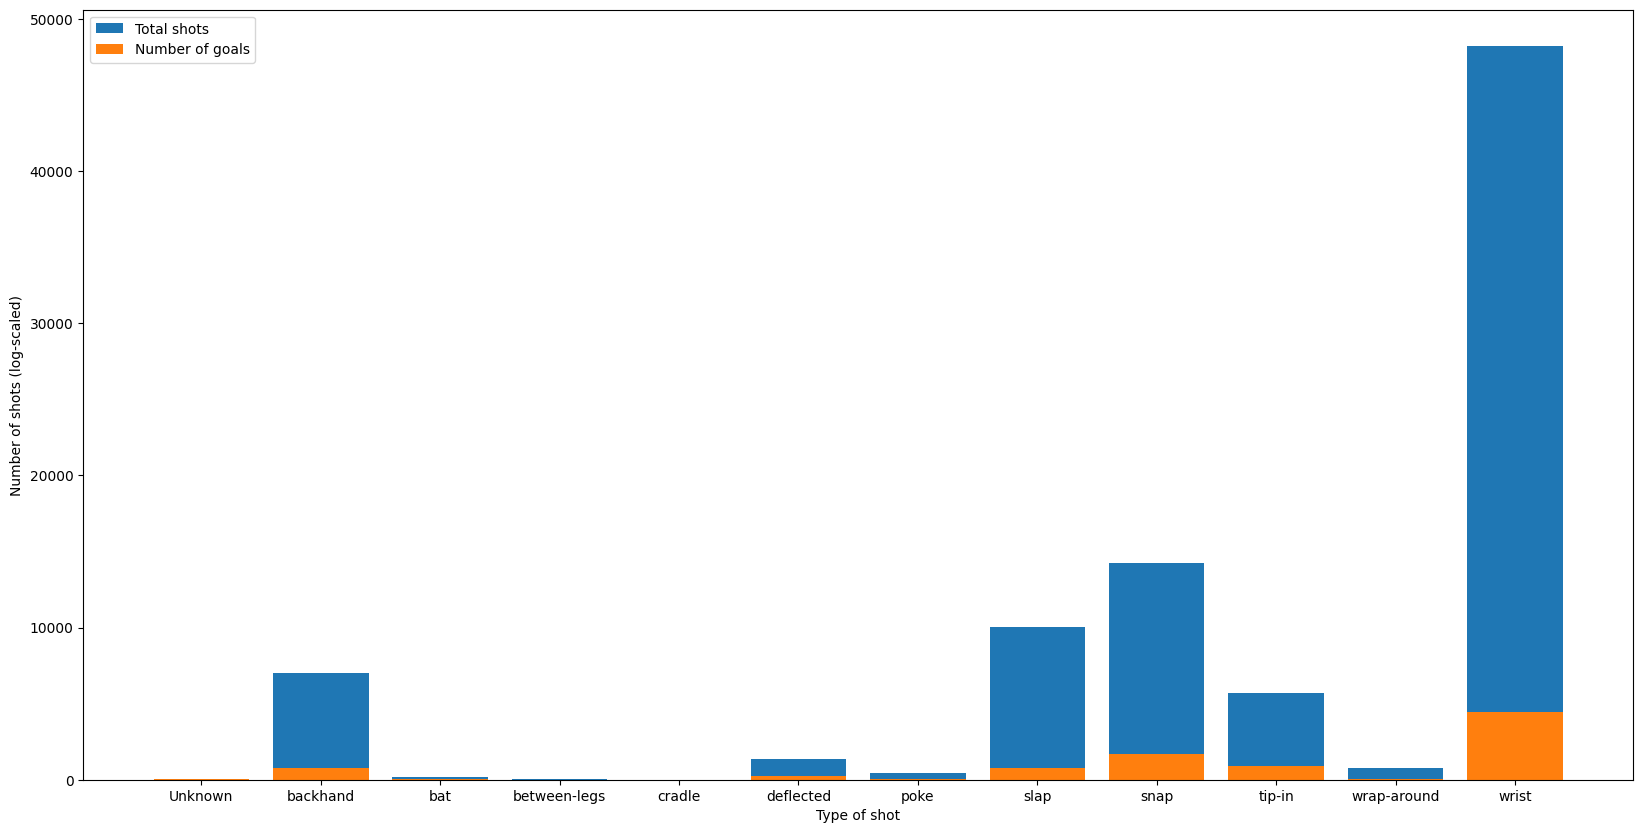

In [40]:
plt.figure(figsize=(20,10))

plt.bar(shots_df.index, shots_df["total_shots"], label="Total shots")
plt.bar(shots_df.index, shots_df["goals"], label="Number of goals")

plt.xlabel("Type of shot")
plt.ylabel("Number of shots (log-scaled)")
#plt.yscale("log")
plt.legend()
plt.plot()